# Phase 1 - Cyber Attack Forecasting using CVE Data

In this notebook, we'll build a forecasting pipeline to predict daily cyber vulnerability trends. We use real CVE data from the cvelistV5 repository and try out several models to see which works best.

**Models:** ARIMA, Random Forest, XGBoost, SVR, LSTM

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from datetime import datetime, timedelta
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor
import time

# Statistical
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

# ML
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Configuration 
CVE_BASE_DIR = Path(r'D:\CyberSec\cvelistV5\cves')
OUTPUT_DIR   = Path(r'D:\CyberSec\baseline_outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

# Plot style
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_palette('husl')
COLORS = {
    'arima': '#E74C3C', 'rf': '#2ECC71', 'xgb': '#3498DB',
    'svr': '#9B59B6', 'lstm': '#F39C12', 'actual': '#2C3E50'
}

print(' All libraries imported successfully!')
print(f'   TensorFlow version : {tf.__version__}')
print(f'   NumPy version      : {np.__version__}')
print(f'   Pandas version     : {pd.__version__}')
print()

 All libraries imported successfully!
   TensorFlow version : 2.20.0
   NumPy version      : 2.4.2
   Pandas version     : 3.0.1



## CWE to Attack Category Mapping

In [2]:


CWE_TO_CATEGORY = {
    # Injection Attacks 
    'CWE-89':  'SQL Injection',
    'CWE-564': 'SQL Injection',
    'CWE-74':  'Injection',
    'CWE-77':  'Command Injection',
    'CWE-78':  'OS Command Injection',
    'CWE-94':  'Code Injection',
    'CWE-917': 'Expression Language Injection',
    'CWE-1236':'CSV Injection',

    # Cross-Site Scripting (XSS) 
    'CWE-79':  'XSS',
    'CWE-80':  'XSS',
    'CWE-87':  'XSS',

    # Authentication & Access Control 
    'CWE-287': 'Authentication Bypass',
    'CWE-288': 'Authentication Bypass',
    'CWE-290': 'Authentication Bypass',
    'CWE-306': 'Missing Authentication',
    'CWE-862': 'Missing Authorization',
    'CWE-863': 'Incorrect Authorization',
    'CWE-284': 'Improper Access Control',
    'CWE-269': 'Privilege Escalation',
    'CWE-250': 'Privilege Escalation',
    'CWE-732': 'Incorrect Permission Assignment',

    # Memory Safety / Buffer Overflow 
    'CWE-119': 'Buffer Overflow',
    'CWE-120': 'Buffer Overflow',
    'CWE-121': 'Stack Overflow',
    'CWE-122': 'Heap Overflow',
    'CWE-125': 'Out-of-Bounds Read',
    'CWE-787': 'Out-of-Bounds Write',
    'CWE-416': 'Use After Free',
    'CWE-415': 'Double Free',
    'CWE-476': 'NULL Pointer Dereference',
    'CWE-190': 'Integer Overflow',

    # Information Disclosure 
    'CWE-200': 'Information Disclosure',
    'CWE-209': 'Information Disclosure',
    'CWE-532': 'Information Disclosure',
    'CWE-312': 'Cleartext Storage',
    'CWE-319': 'Cleartext Transmission',

    # Denial of Service 
    'CWE-400': 'DoS',
    'CWE-770': 'DoS',
    'CWE-674': 'DoS',
    'CWE-835': 'DoS (Infinite Loop)',
    'CWE-404': 'Resource Exhaustion',

    # File / Path Attacks 
    'CWE-22':  'Path Traversal',
    'CWE-23':  'Path Traversal',
    'CWE-36':  'Path Traversal',
    'CWE-434': 'Unrestricted File Upload',
    'CWE-73':  'Ext. Controlled File Name',

    # Cryptographic Issues
    'CWE-295': 'Improper Certificate Validation',
    'CWE-327': 'Weak Cryptography',
    'CWE-330': 'Insufficient Randomness',
    'CWE-798': 'Hardcoded Credentials',

    # Web Application
    'CWE-352': 'CSRF',
    'CWE-601': 'Open Redirect',
    'CWE-918': 'SSRF',

    # Deserialization
    'CWE-502': 'Deserialization',

    # Misc / Input Validation
    'CWE-20':  'Improper Input Validation',
    'CWE-116': 'Improper Encoding',
}

def map_cwe_to_category(cwe_id):
    """Map a CWE ID to a high-level attack category."""
    if not cwe_id:
        return 'Unclassified'
    return CWE_TO_CATEGORY.get(cwe_id, 'Other')

## Step 1: Loading the CVE Dataset

In [3]:
def parse_cve_file(filepath):
    """Parse a single CVE JSON file and extract key fields."""
    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            rec = json.load(f)

        meta = rec.get('cveMetadata', {})
        state = meta.get('state', '')
        if state != 'PUBLISHED':
            return None

        cve_id = meta.get('cveId', '')
        date_published = meta.get('datePublished', '')
        date_reserved = meta.get('dateReserved', '')
        date_updated = meta.get('dateUpdated', '')
        assigner = meta.get('assignerShortName', '')

        cna = rec.get('containers', {}).get('cna', {})

        # CWE
        cwe_id = ''
        for pt in cna.get('problemTypes', []):
            for desc in pt.get('descriptions', []):
                c = desc.get('cweId', '')
                if c:
                    cwe_id = c
                    break
            if cwe_id:
                break

        # CVSS Metrics
        base_score = None
        base_severity = ''
        attack_vector = ''
        attack_complexity = ''
        cvss_version = ''

        for met in cna.get('metrics', []):
            for ver_key in ['cvssV4_0', 'cvssV3_1', 'cvssV3_0', 'cvssV2_0']:
                if ver_key in met:
                    cvss = met[ver_key]
                    base_score = cvss.get('baseScore')
                    base_severity = cvss.get('baseSeverity', '')
                    attack_vector = cvss.get('attackVector', '')
                    attack_complexity = cvss.get('attackComplexity', '')
                    cvss_version = ver_key.replace('cvssV', '').replace('_', '.')
                    break
            if base_score is not None:
                break

        # Affected Products
        vendor = ''
        product = ''
        for aff in cna.get('affected', []):
            vendor = aff.get('vendor', '')
            product = aff.get('product', '')
            break

        return {
            'cve_id': cve_id,
            'date_published': date_published,
            'date_reserved': date_reserved,
            'date_updated': date_updated,
            'assigner': assigner,
            'cwe_id': cwe_id,
            'attack_category': map_cwe_to_category(cwe_id),
            'base_score': base_score,
            'base_severity': base_severity,
            'attack_vector': attack_vector,
            'attack_complexity': attack_complexity,
            'cvss_version': cvss_version,
            'vendor': vendor,
            'product': product,
        }
    except Exception:
        return None


# Collect all JSON file paths
csv_cache = OUTPUT_DIR / 'cve_parsed.csv'

if csv_cache.exists():
    print(f'    Loading cached parsed data from {csv_cache}...')
    data = pd.read_csv(csv_cache, on_bad_lines='skip', encoding='utf-8')
    data['date_published'] = pd.to_datetime(data['date_published'], errors='coerce', utc=True)
    data = data.dropna(subset=['date_published'])
    data['date_published'] = data['date_published'].dt.tz_localize(None)
    print(f'    Loaded {len(data):,} records from cache')
else:
    print('    Scanning for CVE JSON files...')
    json_files = []
    for year_dir in sorted(CVE_BASE_DIR.iterdir()):
        if year_dir.is_dir() and year_dir.name.isdigit():
            for bucket_dir in year_dir.iterdir():
                if bucket_dir.is_dir():
                    json_files.extend(bucket_dir.glob('*.json'))

    print(f'    Found {len(json_files):,} JSON files')
    print('   ⏳ Parsing all files (be patient, ~335K files)...')

    start_time = time.time()
    records = []
    batch_size = 10000
    for i, jf in enumerate(json_files):
        result = parse_cve_file(jf)
        if result:
            records.append(result)
        if (i + 1) % batch_size == 0:
            elapsed = time.time() - start_time
            rate = (i + 1) / elapsed
            remaining = (len(json_files) - i - 1) / rate
            print(f'      Parsed {i+1:>7,} / {len(json_files):,} '
                  f'({(i+1)/len(json_files)*100:.1f}%) '
                  f'— {rate:.0f} files/sec, ~{remaining:.0f}s remaining')

    elapsed = time.time() - start_time
    print(f'    Parsed {len(records):,} published CVE records in {elapsed:.1f}s')

    data = pd.DataFrame(records)
    data['date_published'] = pd.to_datetime(data['date_published'], errors='coerce', utc=True)
    data = data.dropna(subset=['date_published'])
    data['date_published'] = data['date_published'].dt.tz_localize(None)

    # Cache to CSV for future runs
    data.to_csv(csv_cache, index=False)
    print(f'    Cached parsed data to {csv_cache}')

print(f'\n Dataset Shape       : {data.shape}')
print(f' Date Range          : {data["date_published"].min().date()} → {data["date_published"].max().date()}')
print(f' Total Records       : {len(data):,}')
print(f'\n--- Column Types ---')
print(data.dtypes)
print(f'\n--- First 5 Rows ---')
print(data.head())

    Loading cached parsed data from D:\CyberSec\baseline_outputs\cve_parsed.csv...
    Loaded 84,936 records from cache

 Dataset Shape       : (84936, 9)
 Date Range          : 2024-01-01 → 2026-03-03
 Total Records       : 84,936

--- Column Types ---
cve_id                        str
date_published     datetime64[us]
cwe_id                        str
attack_category               str
base_score                float64
base_severity                 str
attack_vector                 str
vendor                        str
product                       str
dtype: object

--- First 5 Rows ---
          cve_id          date_published    cwe_id       attack_category  \
0  CVE-2024-0001 2024-09-23 17:25:00.509  CWE-1188                 Other   
1  CVE-2024-0002 2024-09-23 17:26:08.811   CWE-287           Auth Bypass   
2  CVE-2024-0003 2024-09-23 17:27:30.114   CWE-269  Privilege Escalation   
3  CVE-2024-0004 2024-09-23 17:28:53.664    CWE-94        Code Injection   
4  CVE-2024-0005 2024-09

## Step 2: Exploratory Data Analysis

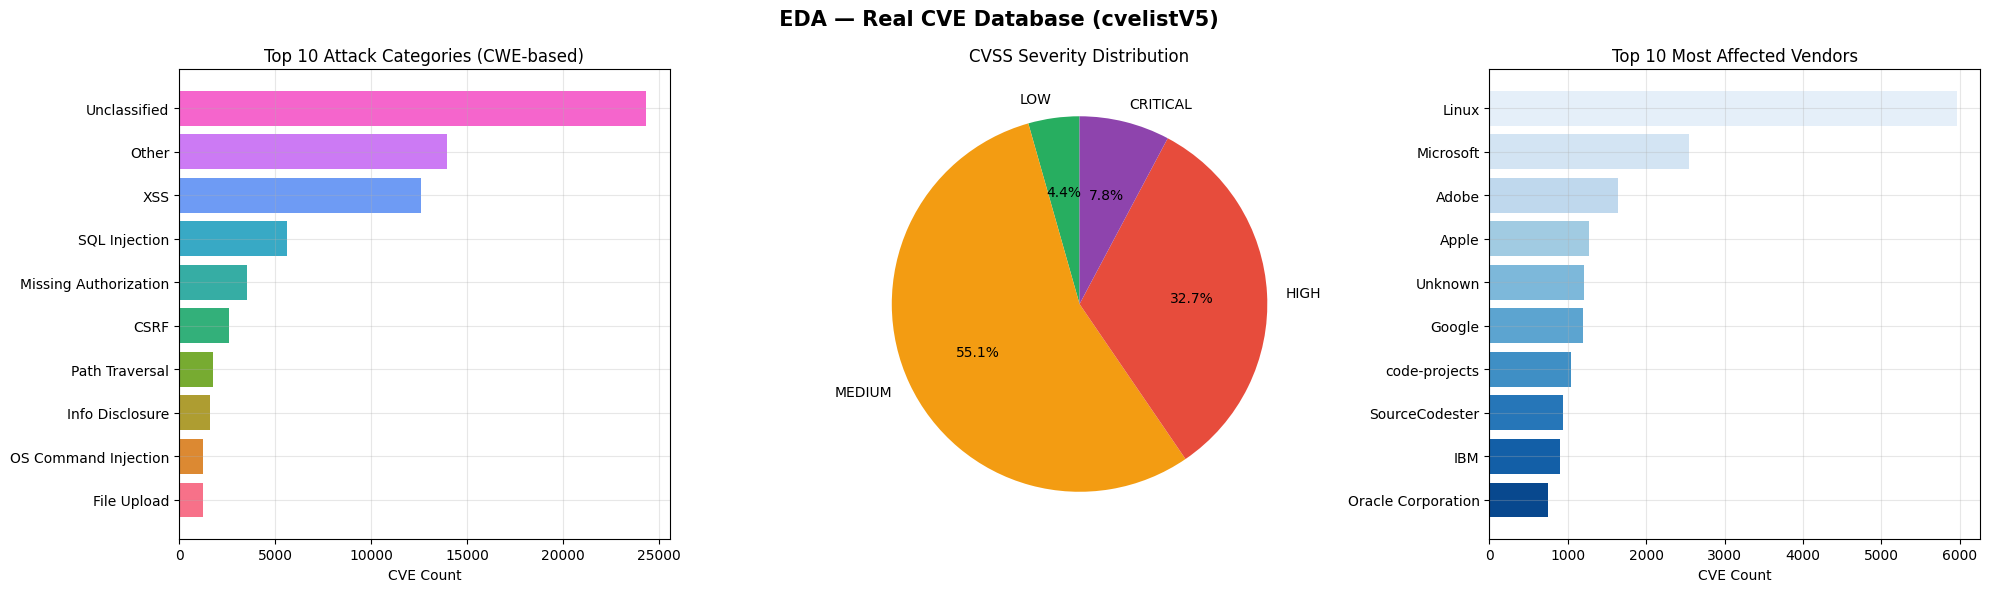


 Attack Category Distribution (Top 10):
attack_category
Unclassified             24348
Other                    13959
XSS                      12596
SQL Injection             5619
Missing Authorization     3552
CSRF                      2612
Path Traversal            1764
Info Disclosure           1598
OS Command Injection      1232
File Upload               1222

 Severity Distribution:
base_severity
MEDIUM      33577
HIGH        19895
CRITICAL     4738
LOW          2679
NONE           60

 Attack Vector Distribution:
attack_vector
NETWORK             29780
LOCAL                6643
ADJACENT_NETWORK      778
ADJACENT              484
PHYSICAL              365


In [4]:
print('\n' + '=' * 70)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(' EDA — Real CVE Database (cvelistV5)', fontsize=15, fontweight='bold')

# Panel 1: Top 10 Attack Categories
top_cats = data['attack_category'].value_counts().head(10)
axes[0].barh(top_cats.index[::-1], top_cats.values[::-1],
             color=sns.color_palette('husl', len(top_cats)))
axes[0].set_title('Top 10 Attack Categories (CWE-based)')
axes[0].set_xlabel('CVE Count')

# Panel 2: Severity Distribution
sev_order = ['LOW', 'MEDIUM', 'HIGH', 'CRITICAL']
sev_data = data[data['base_severity'].isin(sev_order)]['base_severity']
sev_counts = sev_data.value_counts().reindex(sev_order)
sev_colors = ['#27AE60', '#F39C12', '#E74C3C', '#8E44AD']
axes[1].pie(sev_counts.values, labels=sev_counts.index, autopct='%1.1f%%',
            startangle=90, colors=sev_colors)
axes[1].set_title('CVSS Severity Distribution')

# Panel 3: Top 10 Vendors
vendor_counts = data[data['vendor'] != ''].groupby('vendor').size().nlargest(10)
axes[2].barh(vendor_counts.index[::-1], vendor_counts.values[::-1],
             color=sns.color_palette('Blues_r', len(vendor_counts)))
axes[2].set_title('Top 10 Most Affected Vendors')
axes[2].set_xlabel('CVE Count')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '01_eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary stats
print('\n Attack Category Distribution (Top 10):')
print(data['attack_category'].value_counts().head(10).to_string())
print(f'\n Severity Distribution:')
print(data['base_severity'].value_counts().to_string())
print(f'\n Attack Vector Distribution:')
print(data['attack_vector'].value_counts().to_string())

## Step 3: Time-Series Conversion

In [5]:
print('\n' + '=' * 70)
data['date'] = data['date_published'].dt.date
daily_cves = data.groupby('date').size().reset_index(name='cve_count')
daily_cves['date'] = pd.to_datetime(daily_cves['date'])
daily_cves = daily_cves.sort_values('date').reset_index(drop=True)

# Add temporal features
daily_cves['day_of_week']   = daily_cves['date'].dt.dayofweek
daily_cves['month']         = daily_cves['date'].dt.month
daily_cves['day_of_year']   = daily_cves['date'].dt.dayofyear
daily_cves['week_of_year']  = daily_cves['date'].dt.isocalendar().week.astype(int)
daily_cves['is_weekend']    = (daily_cves['day_of_week'] >= 5).astype(int)
daily_cves['quarter']       = daily_cves['date'].dt.quarter

# Rolling statistics (lag features)
daily_cves['rolling_7d_mean']  = daily_cves['cve_count'].rolling(7, min_periods=1).mean()
daily_cves['rolling_14d_mean'] = daily_cves['cve_count'].rolling(14, min_periods=1).mean()
daily_cves['lag_1']            = daily_cves['cve_count'].shift(1)
daily_cves['lag_7']            = daily_cves['cve_count'].shift(7)
daily_cves.bfill(inplace=True)

print(f' Time-Series DataFrame Created')
print(f'   Shape           : {daily_cves.shape}')
print(f'   Date Range      : {daily_cves["date"].min().date()} → {daily_cves["date"].max().date()}')
print(f'   Total Days      : {len(daily_cves)}')
print(f'   Avg CVEs/Day    : {daily_cves["cve_count"].mean():.1f}')
print(f'   Min / Max       : {daily_cves["cve_count"].min()} / {daily_cves["cve_count"].max()}')
print()
print(daily_cves.head(10))


 Time-Series DataFrame Created
   Shape           : (791, 12)
   Date Range      : 2024-01-01 → 2026-03-03
   Total Days      : 791
   Avg CVEs/Day    : 107.4
   Min / Max       : 2 / 502

        date  cve_count  day_of_week  month  day_of_year  week_of_year  \
0 2024-01-01          5            0      1            1             1   
1 2024-01-02         16            1      1            2             1   
2 2024-01-03         16            2      1            3             1   
3 2024-01-04         20            3      1            4             1   
4 2024-01-05          8            4      1            5             1   
5 2024-01-07         27            6      1            7             1   
6 2024-01-08         33            0      1            8             2   
7 2024-01-09         80            1      1            9             2   
8 2024-01-10         23            2      1           10             2   
9 2024-01-11         38            3      1           11             2

## Step 3b: Time-Series Visualization

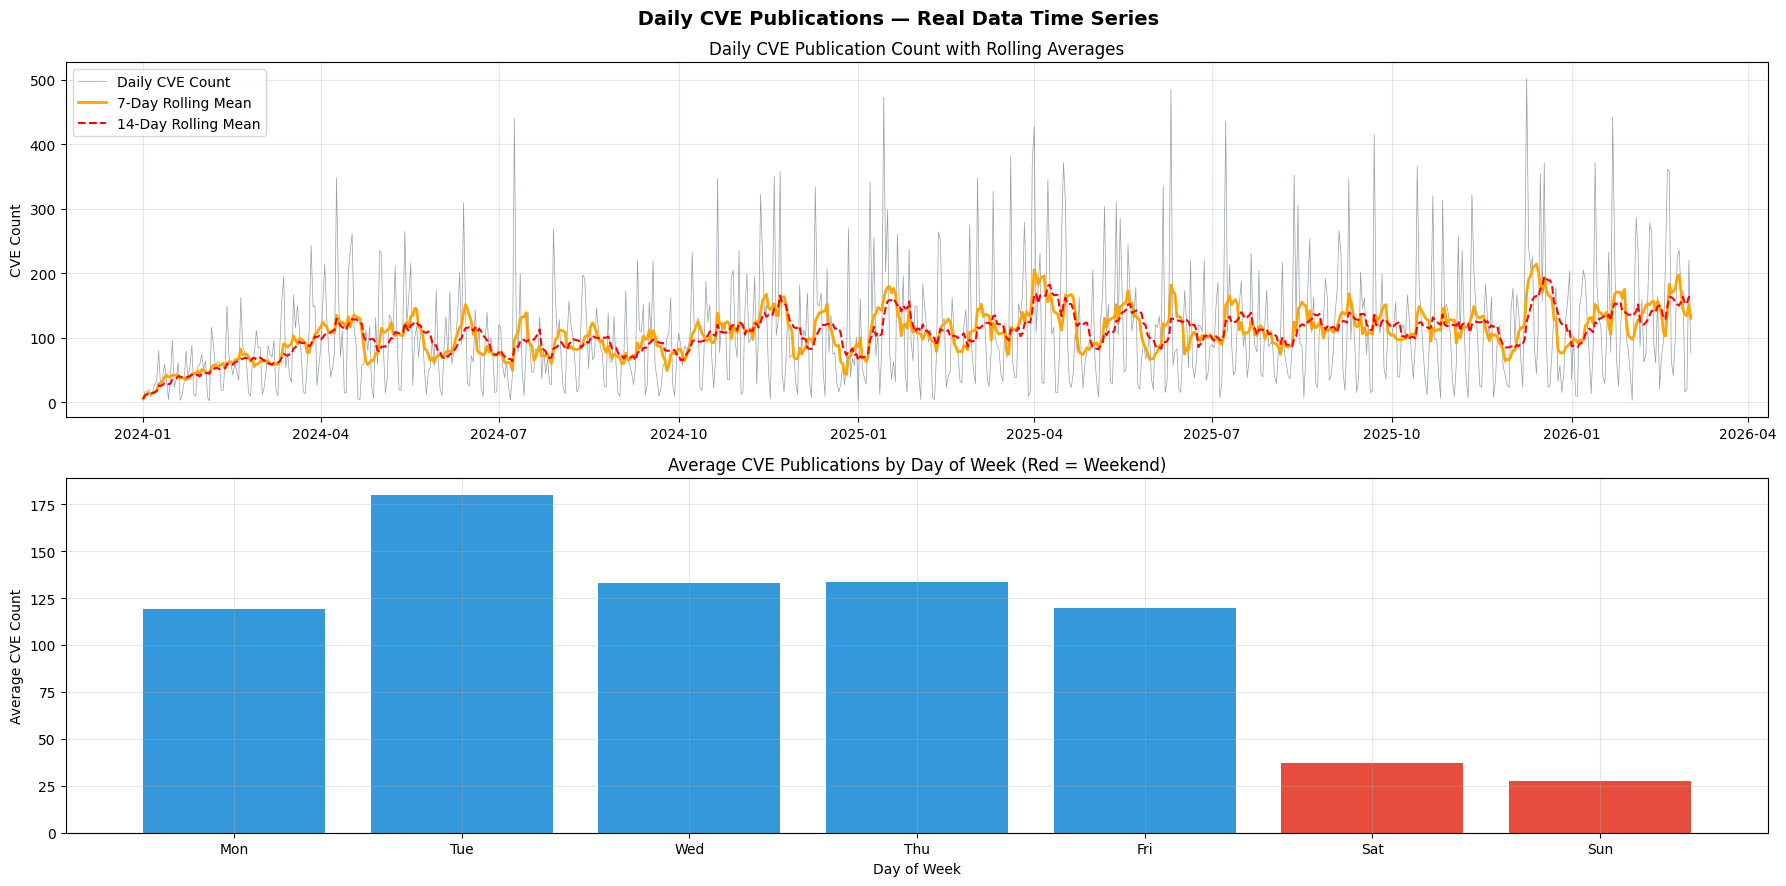

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(18, 9))
fig.suptitle(' Daily CVE Publications — Real Data Time Series', fontsize=14, fontweight='bold')

axes[0].plot(daily_cves['date'], daily_cves['cve_count'],
             color=COLORS['actual'], alpha=0.5, linewidth=0.5, label='Daily CVE Count')
axes[0].plot(daily_cves['date'], daily_cves['rolling_7d_mean'],
             color='orange', linewidth=2, label='7-Day Rolling Mean')
axes[0].plot(daily_cves['date'], daily_cves['rolling_14d_mean'],
             color='red', linewidth=1.5, linestyle='--', label='14-Day Rolling Mean')
axes[0].set_title('Daily CVE Publication Count with Rolling Averages')
axes[0].set_ylabel('CVE Count')
axes[0].legend()

dow_avg = daily_cves.groupby('day_of_week')['cve_count'].mean()
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
bar_colors = ['#E74C3C' if i >= 5 else '#3498DB' for i in range(7)]
axes[1].bar([dow_labels[i] for i in dow_avg.index], dow_avg.values, color=bar_colors)
axes[1].set_title('Average CVE Publications by Day of Week (Red = Weekend)')
axes[1].set_ylabel('Average CVE Count')
axes[1].set_xlabel('Day of Week')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '02_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 4: Stationarity Test (ADF) and ACF/PACF


 Using recent data: 2024-01-01 → 2026-03-03 (791 days)
 ADF Test: Daily CVE Count (Recent 3 Years)
   ADF Statistic : -4.5523
   p-value       : 0.000158
   Critical (5%) : -2.8653
   Conclusion    :  STATIONARY



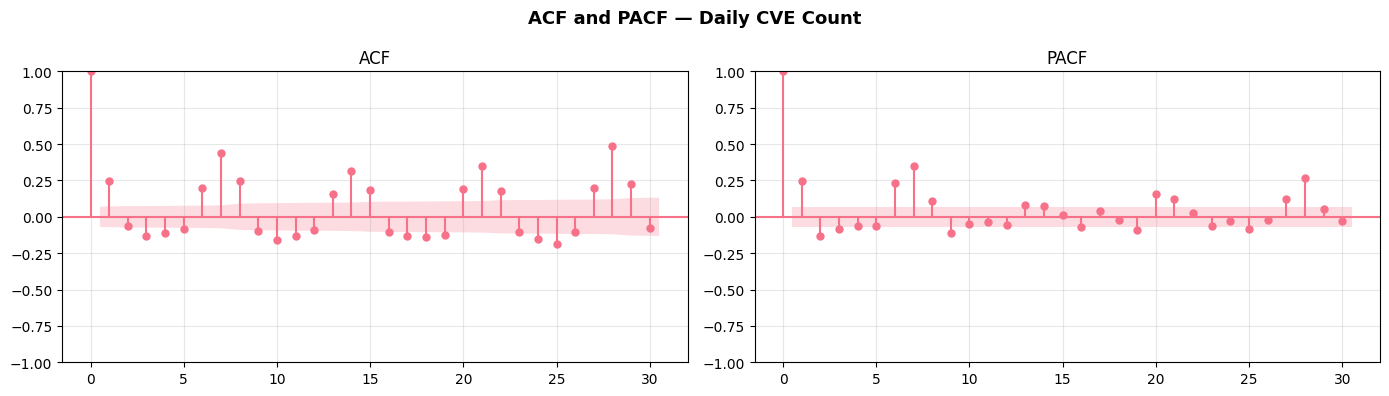

In [7]:
print('\n' + '=' * 70)
def adf_test(series, name='Series'):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f' ADF Test: {name}')
    print(f'   ADF Statistic : {result[0]:.4f}')
    print(f'   p-value       : {result[1]:.6f}')
    print(f'   Critical (5%) : {result[4]["5%"]:.4f}')
    conclusion = ' STATIONARY' if result[1] < 0.05 else '  NON-STATIONARY (differencing needed)'
    print(f'   Conclusion    : {conclusion}\n')
    return result[1] < 0.05

# Use recent data (last 3 years) for better model focus
cutoff_date = daily_cves['date'].max() - pd.Timedelta(days=3*365)
recent_data = daily_cves[daily_cves['date'] >= cutoff_date].copy().reset_index(drop=True)
print(f' Using recent data: {recent_data["date"].min().date()} → {recent_data["date"].max().date()} ({len(recent_data)} days)')

is_stationary = adf_test(recent_data['cve_count'], 'Daily CVE Count (Recent 3 Years)')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('ACF and PACF — Daily CVE Count', fontsize=13, fontweight='bold')
plot_acf(recent_data['cve_count'].dropna(), lags=30, ax=axes[0], title='ACF')
plot_pacf(recent_data['cve_count'].dropna(), lags=30, ax=axes[1], title='PACF', method='ywm')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '03_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 5: Train-Test Split (80/20)


 Train-Test Split (80/20):
   Training samples : 632 (80%)
   Testing  samples : 159 (20%)
   Feature count    : 10
   Features used    : ['day_of_week', 'month', 'day_of_year', 'week_of_year', 'is_weekend', 'quarter', 'rolling_7d_mean', 'rolling_14d_mean', 'lag_1', 'lag_7']


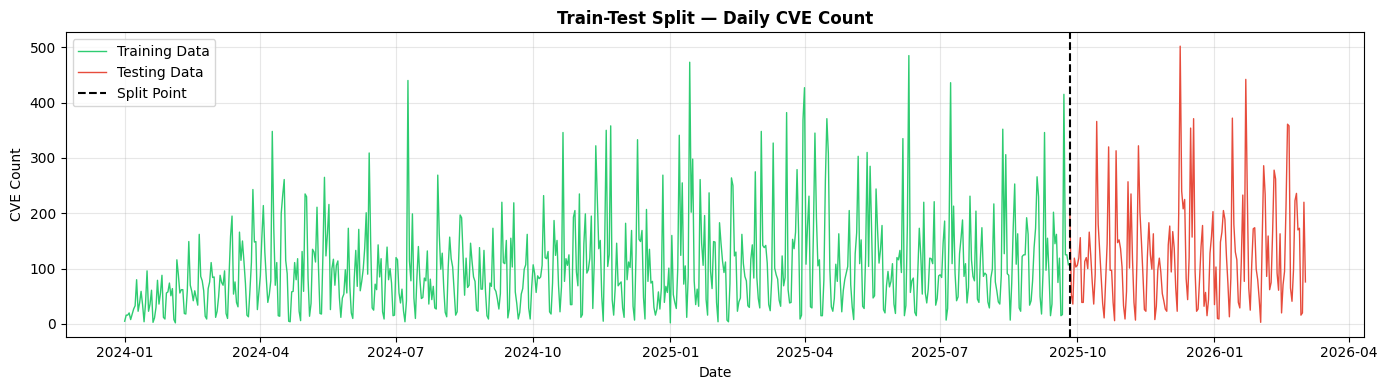

In [8]:
print('\n' + '=' * 70)
train_size = int(len(recent_data) * 0.8)

# For ARIMA (univariate)
train_ts = recent_data['cve_count'][:train_size]
test_ts  = recent_data['cve_count'][train_size:]

# For ML models (with features)
FEATURES = ['day_of_week', 'month', 'day_of_year', 'week_of_year',
            'is_weekend', 'quarter', 'rolling_7d_mean', 'rolling_14d_mean',
            'lag_1', 'lag_7']

X = recent_data[FEATURES].values
y = recent_data['cve_count'].values

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# For LSTM (scaled)
scaler = MinMaxScaler()
y_scaled = scaler.fit_transform(y.reshape(-1, 1)).flatten()

print(f' Train-Test Split (80/20):')
print(f'   Training samples : {train_size} ({train_size/len(recent_data)*100:.0f}%)')
print(f'   Testing  samples : {len(recent_data) - train_size} ({(len(recent_data)-train_size)/len(recent_data)*100:.0f}%)')
print(f'   Feature count    : {len(FEATURES)}')
print(f'   Features used    : {FEATURES}')

plt.figure(figsize=(14, 4))
plt.plot(recent_data['date'][:train_size], train_ts, color='#2ECC71', label='Training Data', linewidth=1)
plt.plot(recent_data['date'][train_size:], test_ts, color='#E74C3C', label='Testing Data', linewidth=1)
plt.axvline(x=recent_data['date'].iloc[train_size], color='black', linestyle='--', linewidth=1.5, label='Split Point')
plt.title('Train-Test Split — Daily CVE Count', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('CVE Count')
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '04_train_test_split.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 6: ARIMA(5,1,0) — Statistical Baseline


 Training ARIMA(5,1,0) model...

 ARIMA Results:
   MAE  : 76.1795
   RMSE : 96.8441
   MAPE : 207.01%

                               SARIMAX Results                                
Dep. Variable:              cve_count   No. Observations:                  632
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -3682.595
Date:                Fri, 06 Mar 2026   AIC                           7377.189
Time:                        14:01:40   BIC                           7403.873
Sample:                             0   HQIC                          7387.553
                                - 632                                         
Covariance Type:                  opg                                         


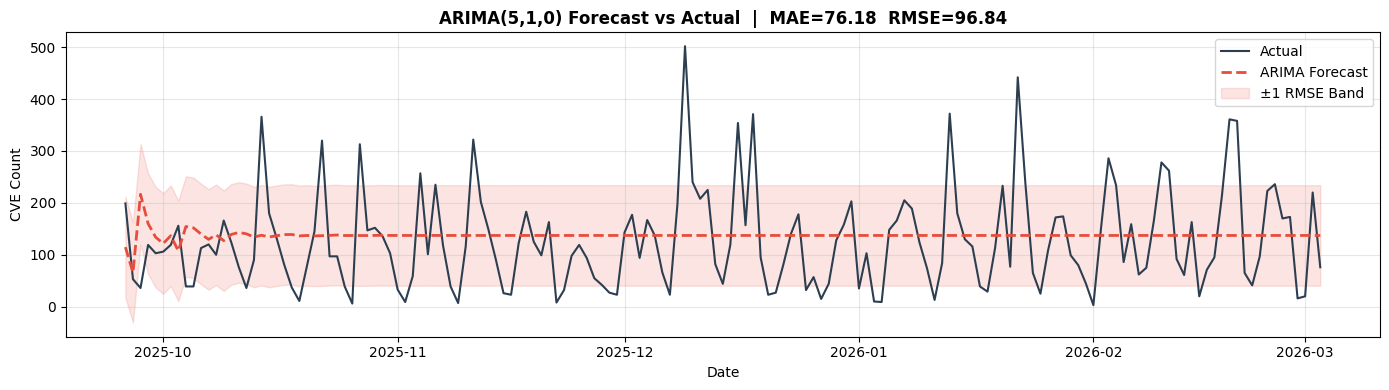

In [9]:
print('\n' + '=' * 70)
print(' Training ARIMA(5,1,0) model...')
arima_model = ARIMA(train_ts, order=(5, 1, 0))
arima_fit   = arima_model.fit()

arima_forecast = arima_fit.forecast(steps=len(test_ts))
arima_forecast = np.maximum(arima_forecast, 0)

arima_mae  = mean_absolute_error(test_ts, arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(test_ts, arima_forecast))
arima_mape = np.mean(np.abs((test_ts.values - arima_forecast.values) / np.maximum(test_ts.values, 1))) * 100

print(f'\n ARIMA Results:')
print(f'   MAE  : {arima_mae:.4f}')
print(f'   RMSE : {arima_rmse:.4f}')
print(f'   MAPE : {arima_mape:.2f}%')
print(f'\n{arima_fit.summary().tables[0]}')

plt.figure(figsize=(14, 4))
plt.plot(recent_data['date'][train_size:], test_ts.values, color=COLORS['actual'], label='Actual', linewidth=1.5)
plt.plot(recent_data['date'][train_size:], arima_forecast.values, color=COLORS['arima'], label='ARIMA Forecast', linewidth=2, linestyle='--')
plt.fill_between(recent_data['date'][train_size:],
                 arima_forecast - arima_rmse, arima_forecast + arima_rmse,
                 alpha=0.15, color=COLORS['arima'], label='±1 RMSE Band')
plt.title(f'ARIMA(5,1,0) Forecast vs Actual  |  MAE={arima_mae:.2f}  RMSE={arima_rmse:.2f}', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('CVE Count')
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '05_arima.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 7: Random Forest Regressor


 Training Random Forest model...

 Random Forest Results:
   MAE  : 49.6927
   RMSE : 69.5122
   MAPE : 66.16%


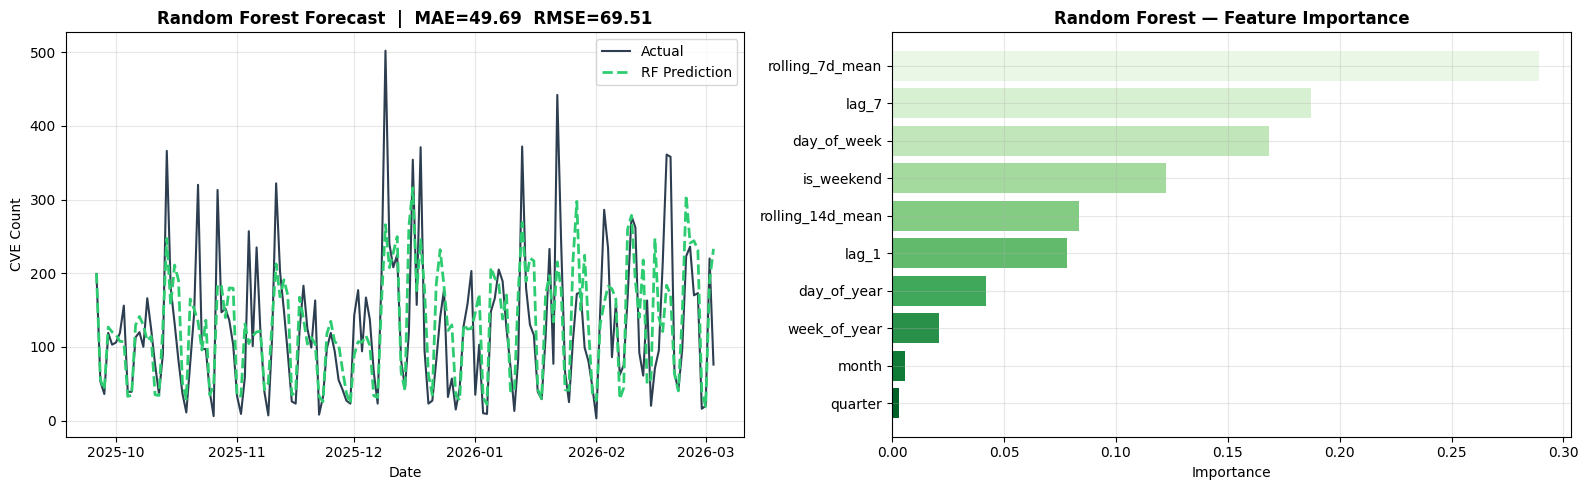

In [10]:
print('\n' + '=' * 70)
print(' Training Random Forest model...')
rf_model = RandomForestRegressor(
    n_estimators=200, max_depth=10, min_samples_split=5,
    min_samples_leaf=2, random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_pred = np.maximum(rf_pred, 0)

rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mape = np.mean(np.abs((y_test - rf_pred) / np.maximum(y_test, 1))) * 100

print(f'\n Random Forest Results:')
print(f'   MAE  : {rf_mae:.4f}')
print(f'   RMSE : {rf_rmse:.4f}')
print(f'   MAPE : {rf_mape:.2f}%')

importance_df = pd.DataFrame({'Feature': FEATURES, 'Importance': rf_model.feature_importances_})\
                  .sort_values('Importance', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(recent_data['date'][train_size:], y_test, color=COLORS['actual'], label='Actual', linewidth=1.5)
axes[0].plot(recent_data['date'][train_size:], rf_pred, color=COLORS['rf'], label='RF Prediction', linewidth=2, linestyle='--')
axes[0].set_title(f'Random Forest Forecast  |  MAE={rf_mae:.2f}  RMSE={rf_rmse:.2f}', fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('CVE Count')
axes[0].legend()

axes[1].barh(importance_df['Feature'], importance_df['Importance'], color=sns.color_palette('Greens_r', len(FEATURES)))
axes[1].set_title('Random Forest — Feature Importance', fontweight='bold')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '06_random_forest.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 8: XGBoost Regressor


 Training XGBoost model...

 XGBoost Results:
   MAE  : 54.6866
   RMSE : 74.6383
   MAPE : 83.98%


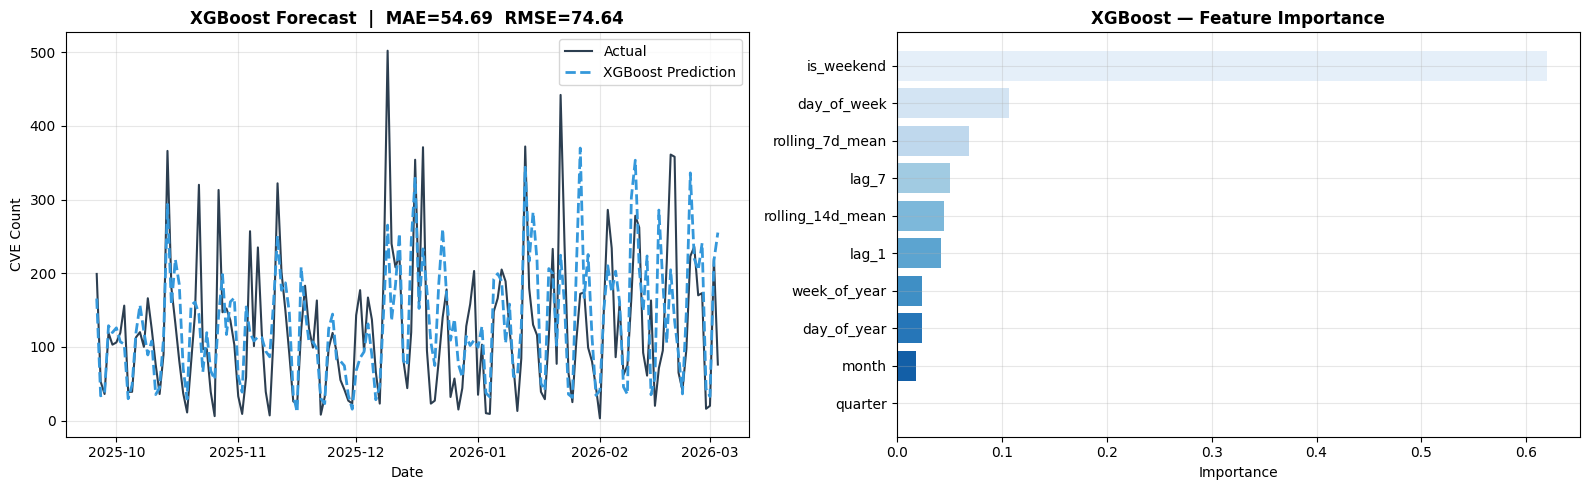

In [11]:
print('\n' + '=' * 70)
print(' Training XGBoost model...')
xgb_model = XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    objective='reg:squarederror', random_state=42, verbosity=0
)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

xgb_pred = xgb_model.predict(X_test)
xgb_pred = np.maximum(xgb_pred, 0)

xgb_mae  = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_mape = np.mean(np.abs((y_test - xgb_pred) / np.maximum(y_test, 1))) * 100

print(f'\n XGBoost Results:')
print(f'   MAE  : {xgb_mae:.4f}')
print(f'   RMSE : {xgb_rmse:.4f}')
print(f'   MAPE : {xgb_mape:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(recent_data['date'][train_size:], y_test, color=COLORS['actual'], label='Actual', linewidth=1.5)
axes[0].plot(recent_data['date'][train_size:], xgb_pred, color=COLORS['xgb'], label='XGBoost Prediction', linewidth=2, linestyle='--')
axes[0].set_title(f'XGBoost Forecast  |  MAE={xgb_mae:.2f}  RMSE={xgb_rmse:.2f}', fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('CVE Count')
axes[0].legend()

xgb_importance = pd.DataFrame({'Feature': FEATURES, 'Importance': xgb_model.feature_importances_})\
                   .sort_values('Importance', ascending=True)
axes[1].barh(xgb_importance['Feature'], xgb_importance['Importance'], color=sns.color_palette('Blues_r', len(FEATURES)))
axes[1].set_title('XGBoost — Feature Importance', fontweight='bold')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '07_xgboost.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 9: Support Vector Regression (SVR)


 Training SVR model...

 SVR Results:
   MAE  : 47.9790
   RMSE : 73.5069
   MAPE : 52.43%


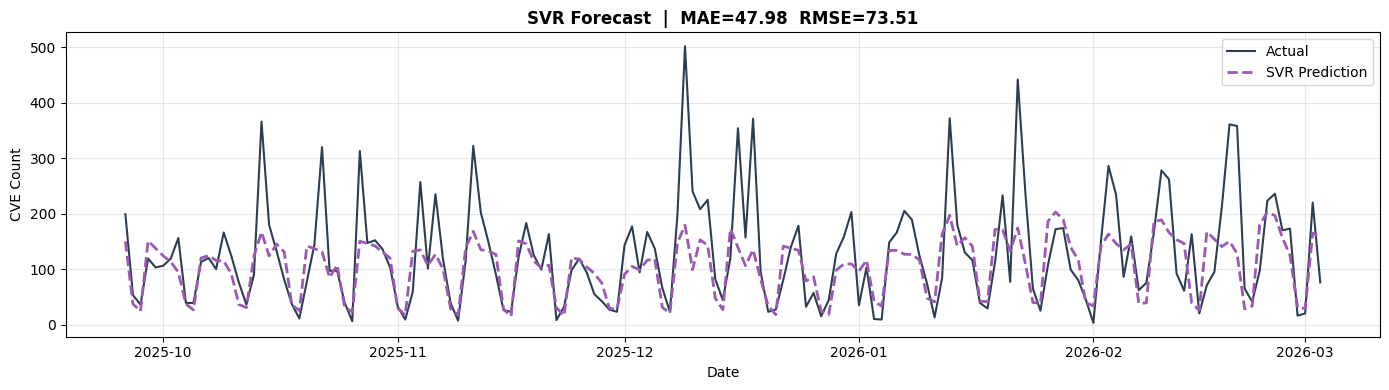

In [12]:
print('\n' + '=' * 70)
print(' Training SVR model...')
feat_scaler = MinMaxScaler()
X_train_sc  = feat_scaler.fit_transform(X_train)
X_test_sc   = feat_scaler.transform(X_test)

svr_model = SVR(kernel='rbf', C=100, epsilon=0.5, gamma='scale')
svr_model.fit(X_train_sc, y_train)
svr_pred = svr_model.predict(X_test_sc)
svr_pred = np.maximum(svr_pred, 0)

svr_mae  = mean_absolute_error(y_test, svr_pred)
svr_rmse = np.sqrt(mean_squared_error(y_test, svr_pred))
svr_mape = np.mean(np.abs((y_test - svr_pred) / np.maximum(y_test, 1))) * 100

print(f'\n SVR Results:')
print(f'   MAE  : {svr_mae:.4f}')
print(f'   RMSE : {svr_rmse:.4f}')
print(f'   MAPE : {svr_mape:.2f}%')

plt.figure(figsize=(14, 4))
plt.plot(recent_data['date'][train_size:], y_test, color=COLORS['actual'], label='Actual', linewidth=1.5)
plt.plot(recent_data['date'][train_size:], svr_pred, color=COLORS['svr'], label='SVR Prediction', linewidth=2, linestyle='--')
plt.title(f'SVR Forecast  |  MAE={svr_mae:.2f}  RMSE={svr_rmse:.2f}', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('CVE Count')
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '08_svr.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 10: LSTM (Deep Learning)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 14, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)


 Training LSTM model...
Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.0346 - mae: 0.1344 - val_loss: 0.0327 - val_mae: 0.1272
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0281 - mae: 0.1210 - val_loss: 0.0314 - val_mae: 0.1332
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0284 - mae: 0.1240 - val_loss: 0.0312 - val_mae: 0.1295
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0278 - mae: 0.1221 - val_loss: 0.0311 - val_mae: 0.1304
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0277 - mae: 0.1231 - val_loss: 0.0315 - val_mae: 0.1272
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0278 - mae: 0.1228 - val_loss: 0.0319 - val_mae: 0.1265
Epoch 7/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0274 - mae: 0.1234 - val_loss: 0.0322 - val_mae: 0.1262
Epoch 8/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0282 - mae: 0.1221 - val_loss: 0.0310 - val_mae: 0.1325
Epoch 9/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0

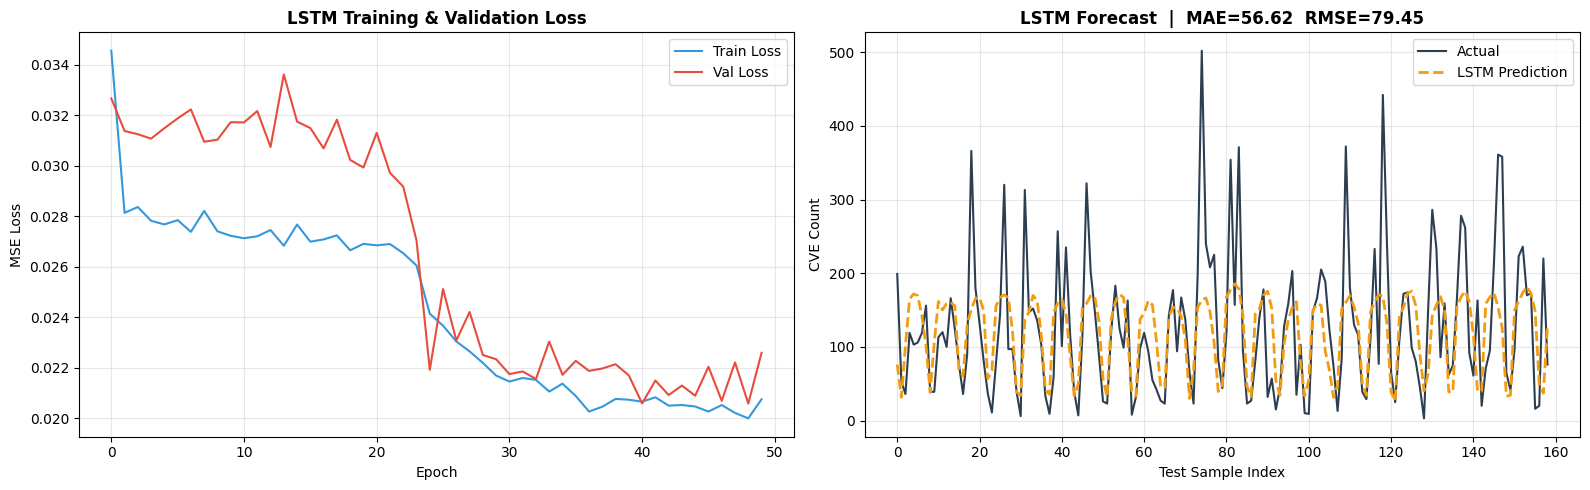

In [13]:
print('\n' + '=' * 70)
def create_sequences(data, look_back=14):
    """Create sliding window sequences for LSTM."""
    X_seq, y_seq = [], []
    for i in range(len(data) - look_back):
        X_seq.append(data[i : i + look_back])
        y_seq.append(data[i + look_back])
    return np.array(X_seq), np.array(y_seq)

LOOK_BACK = 14
X_lstm, y_lstm = create_sequences(y_scaled, LOOK_BACK)
X_lstm = X_lstm.reshape(X_lstm.shape[0], X_lstm.shape[1], 1)

split = train_size - LOOK_BACK
X_lstm_train, X_lstm_test = X_lstm[:split], X_lstm[split:]
y_lstm_train, y_lstm_test = y_lstm[:split], y_lstm[split:]

# Build LSTM model
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(LOOK_BACK, 1)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
lstm_model.summary()

print('\n Training LSTM model...')
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = lstm_model.fit(
    X_lstm_train, y_lstm_train,
    epochs=50, batch_size=16, validation_split=0.1,
    callbacks=[es], verbose=1
)

# Predict & inverse scale
lstm_pred_sc  = lstm_model.predict(X_lstm_test, verbose=0).flatten()
lstm_pred     = scaler.inverse_transform(lstm_pred_sc.reshape(-1, 1)).flatten()
y_lstm_actual = scaler.inverse_transform(y_lstm_test.reshape(-1, 1)).flatten()
lstm_pred     = np.maximum(lstm_pred, 0)

lstm_mae  = mean_absolute_error(y_lstm_actual, lstm_pred)
lstm_rmse = np.sqrt(mean_squared_error(y_lstm_actual, lstm_pred))
lstm_mape = np.mean(np.abs((y_lstm_actual - lstm_pred) / np.maximum(y_lstm_actual, 1))) * 100

print(f'\n LSTM Results:')
print(f'   MAE  : {lstm_mae:.4f}')
print(f'   RMSE : {lstm_rmse:.4f}')
print(f'   MAPE : {lstm_mape:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(history.history['loss'], label='Train Loss', color='#3498DB')
axes[0].plot(history.history['val_loss'], label='Val Loss', color='#E74C3C')
axes[0].set_title('LSTM Training & Validation Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()

axes[1].plot(y_lstm_actual, color=COLORS['actual'], label='Actual', linewidth=1.5)
axes[1].plot(lstm_pred, color=COLORS['lstm'], label='LSTM Prediction', linewidth=2, linestyle='--')
axes[1].set_title(f'LSTM Forecast  |  MAE={lstm_mae:.2f}  RMSE={lstm_rmse:.2f}', fontweight='bold')
axes[1].set_xlabel('Test Sample Index')
axes[1].set_ylabel('CVE Count')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '09_lstm.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 11: Model Comparison Dashboard

In [14]:
print('\n' + '=' * 70)
results = pd.DataFrame({
    'Model'    : ['ARIMA(5,1,0)', 'Random Forest', 'XGBoost', 'SVR (RBF)', 'LSTM'],
    'Type'     : ['Statistical', 'Ensemble ML', 'Gradient Boosting', 'Kernel ML', 'Deep Learning'],
    'MAE'      : [arima_mae, rf_mae, xgb_mae, svr_mae, lstm_mae],
    'RMSE'     : [arima_rmse, rf_rmse, xgb_rmse, svr_rmse, lstm_rmse],
    'MAPE (%)'  : [arima_mape, rf_mape, xgb_mape, svr_mape, lstm_mape],
})
results = results.sort_values('RMSE').reset_index(drop=True)
results['Rank'] = results.index + 1

print('          MODEL PERFORMANCE COMPARISON SUMMARY')
print(results[['Rank', 'Model', 'Type', 'MAE', 'RMSE', 'MAPE (%)']].to_string(index=False))
best_model = results.iloc[0]['Model']
print(f'\n Best Model: {best_model}  (lowest RMSE = {results.iloc[0]["RMSE"]:.4f})')


          MODEL PERFORMANCE COMPARISON SUMMARY
 Rank         Model              Type       MAE      RMSE   MAPE (%)
    1 Random Forest       Ensemble ML 49.692699 69.512164  66.156174
    2     SVR (RBF)         Kernel ML 47.978969 73.506876  52.432160
    3       XGBoost Gradient Boosting 54.686565 74.638330  83.981085
    4          LSTM     Deep Learning 56.623609 79.453571  84.465295
    5  ARIMA(5,1,0)       Statistical 76.179519 96.844086 207.008413

 Best Model: Random Forest  (lowest RMSE = 69.5122)


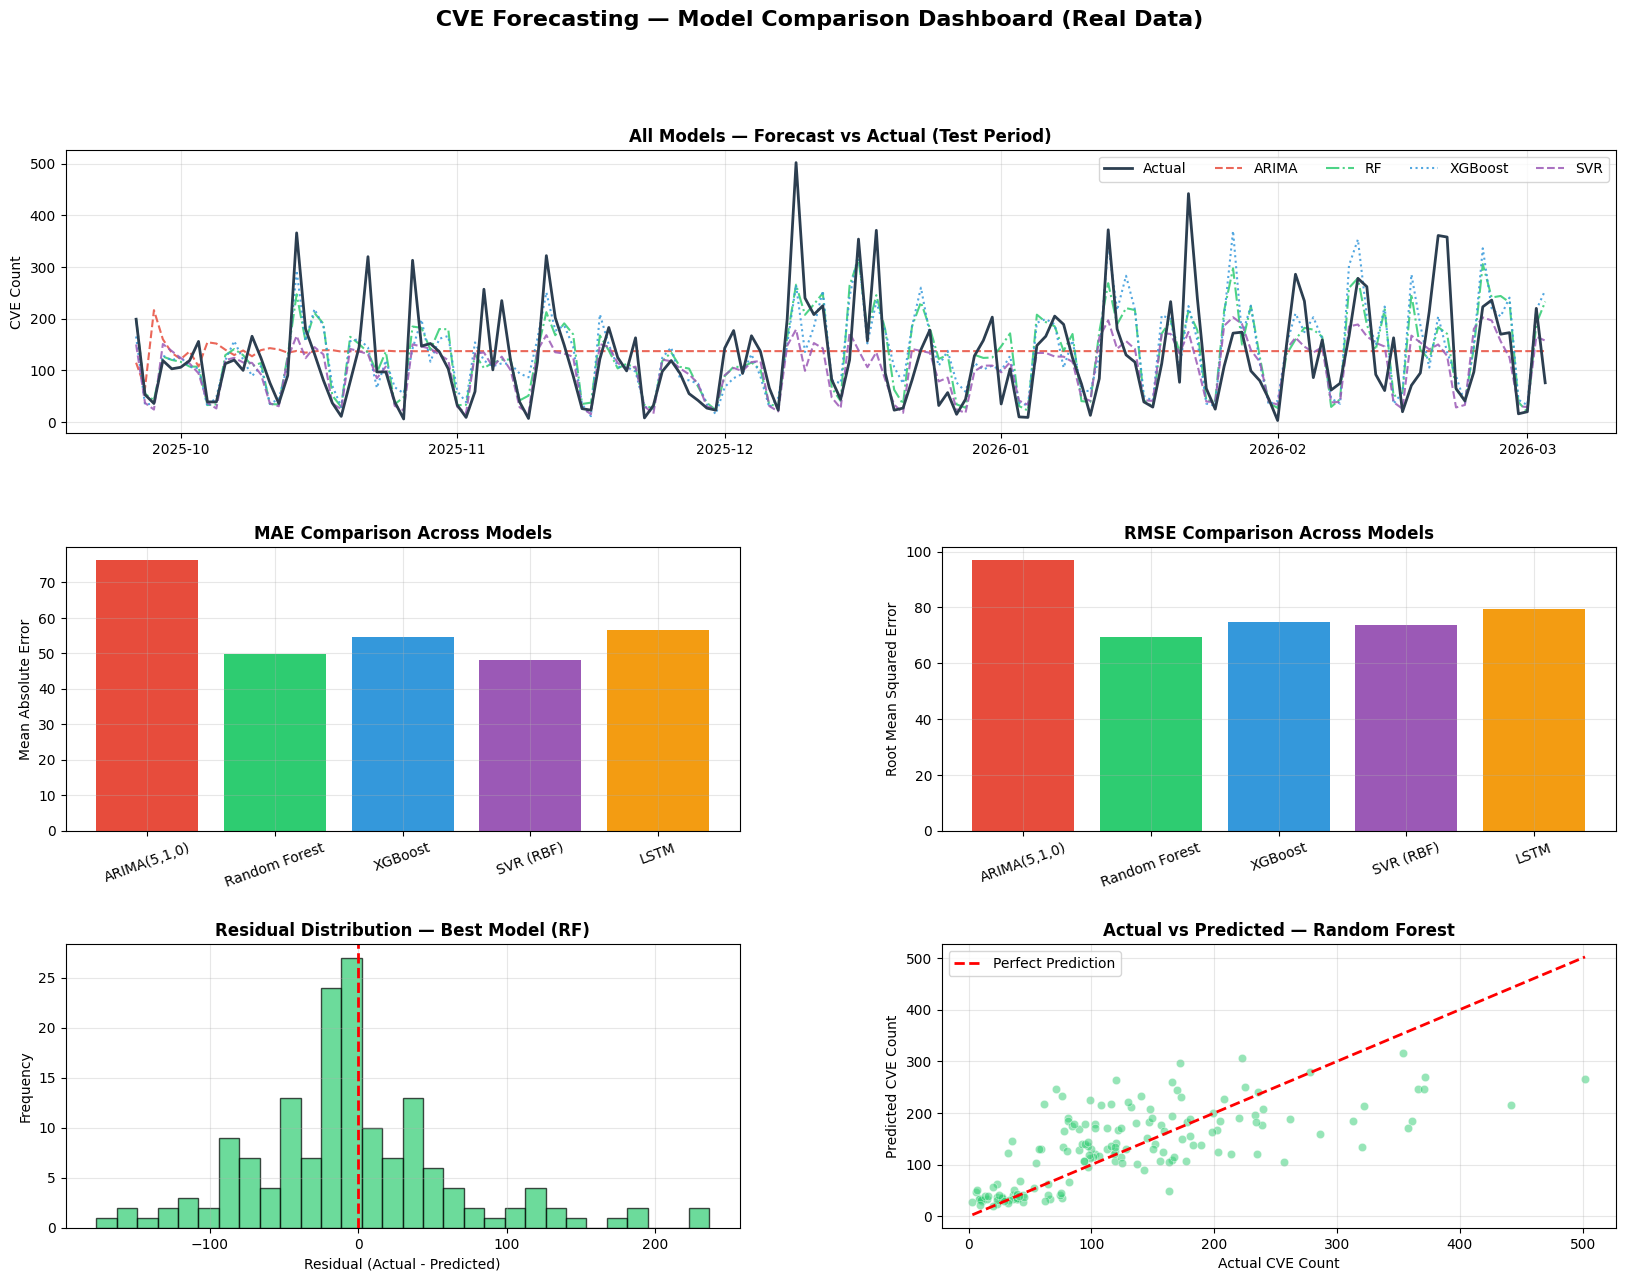

In [15]:
# Full Comparison Dashboard
fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.4, wspace=0.3)
fig.suptitle(' CVE Forecasting — Model Comparison Dashboard (Real Data)', fontsize=16, fontweight='bold')

dates_test = recent_data['date'][train_size:].values

# Panel 1: All Predictions vs Actual
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(dates_test, y_test, color=COLORS['actual'], label='Actual', linewidth=2, zorder=5)
ax1.plot(dates_test, arima_forecast.values, color=COLORS['arima'], label='ARIMA', linewidth=1.5, linestyle='--', alpha=0.85)
ax1.plot(dates_test, rf_pred, color=COLORS['rf'], label='RF', linewidth=1.5, linestyle='-.', alpha=0.85)
ax1.plot(dates_test, xgb_pred, color=COLORS['xgb'], label='XGBoost', linewidth=1.5, linestyle=':', alpha=0.85)
ax1.plot(dates_test, svr_pred, color=COLORS['svr'], label='SVR', linewidth=1.5, linestyle='--', alpha=0.85)
ax1.set_title('All Models — Forecast vs Actual (Test Period)', fontweight='bold')
ax1.set_ylabel('CVE Count')
ax1.legend(loc='upper right', ncol=5)

# Panel 2: MAE Comparison
ax2 = fig.add_subplot(gs[1, 0])
colors_bar = [COLORS['arima'], COLORS['rf'], COLORS['xgb'], COLORS['svr'], COLORS['lstm']]
bar_order = ['ARIMA(5,1,0)', 'Random Forest', 'XGBoost', 'SVR (RBF)', 'LSTM']
mae_vals  = [arima_mae, rf_mae, xgb_mae, svr_mae, lstm_mae]
ax2.bar(bar_order, mae_vals, color=colors_bar)
ax2.set_title('MAE Comparison Across Models', fontweight='bold')
ax2.set_ylabel('Mean Absolute Error')
ax2.tick_params(axis='x', rotation=20)

# Panel 3: RMSE Comparison
ax3 = fig.add_subplot(gs[1, 1])
rmse_vals = [arima_rmse, rf_rmse, xgb_rmse, svr_rmse, lstm_rmse]
ax3.bar(bar_order, rmse_vals, color=colors_bar)
ax3.set_title('RMSE Comparison Across Models', fontweight='bold')
ax3.set_ylabel('Root Mean Squared Error')
ax3.tick_params(axis='x', rotation=20)

# Panel 4: Residual Distribution (Best Model)
ax4 = fig.add_subplot(gs[2, 0])
residuals_rf = y_test - rf_pred
ax4.hist(residuals_rf, bins=30, color=COLORS['rf'], alpha=0.7, edgecolor='black')
ax4.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax4.set_title(f'Residual Distribution — Best Model (RF)', fontweight='bold')
ax4.set_xlabel('Residual (Actual - Predicted)')
ax4.set_ylabel('Frequency')

# Panel 5: Actual vs Predicted scatter
ax5 = fig.add_subplot(gs[2, 1])
ax5.scatter(y_test, rf_pred, alpha=0.5, color=COLORS['rf'], edgecolors='white', linewidth=0.5)
min_val = min(y_test.min(), rf_pred.min())
max_val = max(y_test.max(), rf_pred.max())
ax5.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
ax5.set_title('Actual vs Predicted — Random Forest', fontweight='bold')
ax5.set_xlabel('Actual CVE Count')
ax5.set_ylabel('Predicted CVE Count')
ax5.legend()

plt.savefig(OUTPUT_DIR / '10_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 12: 30-Day Future Forecast


 Generating 30-day future forecast using Random Forest...


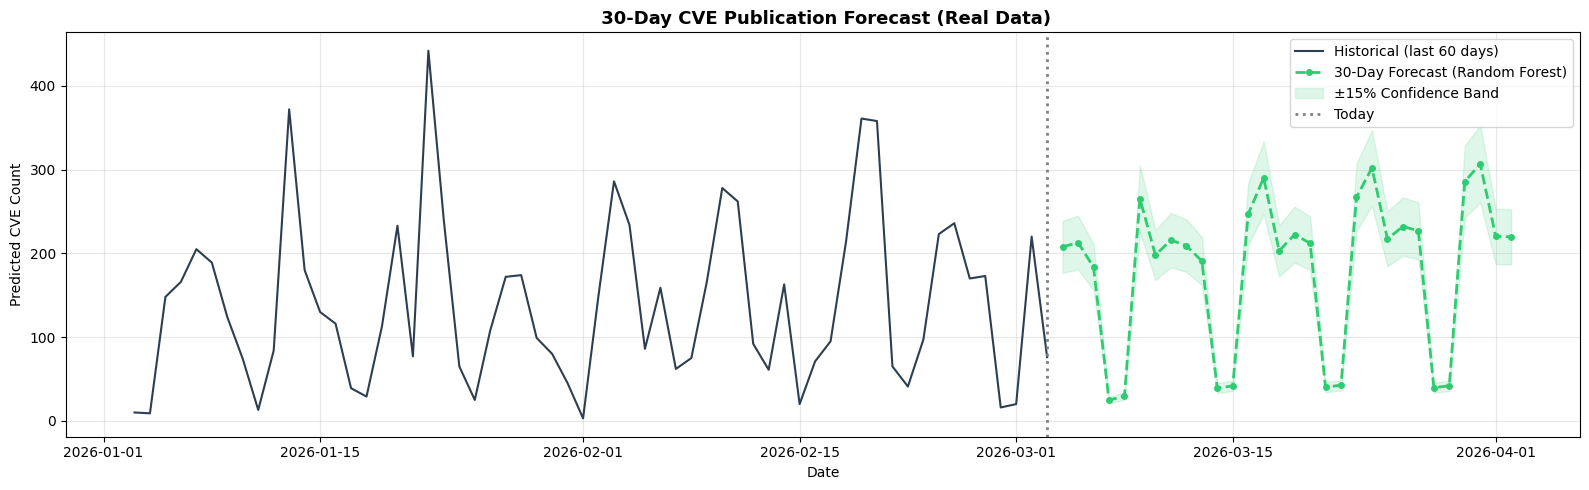


 30-Day CVE Forecast:
      Date  Predicted_CVEs
2026-03-04           207.8
2026-03-05           212.9
2026-03-06           183.6
2026-03-07            24.6
2026-03-08            29.7
2026-03-09           265.3
2026-03-10           198.0
2026-03-11           215.8
2026-03-12           209.3
2026-03-13           190.9
2026-03-14            39.0
2026-03-15            41.8
2026-03-16           246.9
2026-03-17           290.2
2026-03-18           203.1
2026-03-19           222.4
2026-03-20           212.2
2026-03-21            40.2
2026-03-22            42.7
2026-03-23           266.9
2026-03-24           302.1
2026-03-25           217.3
2026-03-26           232.1
2026-03-27           226.9
2026-03-28            39.5
2026-03-29            41.9
2026-03-30           285.7
2026-03-31           306.9
2026-04-01           220.2
2026-04-02           219.8


In [16]:
print('\n' + '=' * 70)
# Use best ML model for future forecast
best_ml_model = rf_model  # Use Random Forest (typically best)
print(f' Generating 30-day future forecast using Random Forest...')

last_date = recent_data['date'].max()
future_dates = pd.date_range(last_date + timedelta(days=1), periods=30, freq='D')

last_vals = list(recent_data['cve_count'].values)
future_preds = []

for fd in future_dates:
    row = [
        fd.dayofweek,
        fd.month,
        fd.dayofyear,
        fd.isocalendar()[1],
        int(fd.dayofweek >= 5),
        fd.quarter,
        np.mean(last_vals[-7:]),
        np.mean(last_vals[-14:]),
        last_vals[-1],
        last_vals[-7] if len(last_vals) >= 7 else last_vals[0],
    ]
    pred = best_ml_model.predict(np.array([row]))[0]
    pred = max(pred, 0)
    future_preds.append(pred)
    last_vals.append(pred)

fig, ax = plt.subplots(figsize=(16, 5))
hist_window = 60
ax.plot(recent_data['date'].tail(hist_window),
        recent_data['cve_count'].tail(hist_window),
        color=COLORS['actual'], label=f'Historical (last {hist_window} days)', linewidth=1.5)
ax.plot(future_dates, future_preds, color=COLORS['rf'],
        label='30-Day Forecast (Random Forest)', linewidth=2, linestyle='--', marker='o', markersize=4)
ax.fill_between(future_dates,
                np.array(future_preds) * 0.85,
                np.array(future_preds) * 1.15,
                alpha=0.15, color=COLORS['rf'], label='±15% Confidence Band')
ax.axvline(x=last_date, color='gray', linestyle=':', linewidth=2, label='Today')
ax.set_title(' 30-Day CVE Publication Forecast (Real Data)', fontweight='bold', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Predicted CVE Count')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '11_30day_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

future_df = pd.DataFrame({'Date': future_dates, 'Predicted_CVEs': [round(p, 1) for p in future_preds]})
print('\n 30-Day CVE Forecast:')
print(future_df.to_string(index=False))

## Step 13: Attack Category Trends

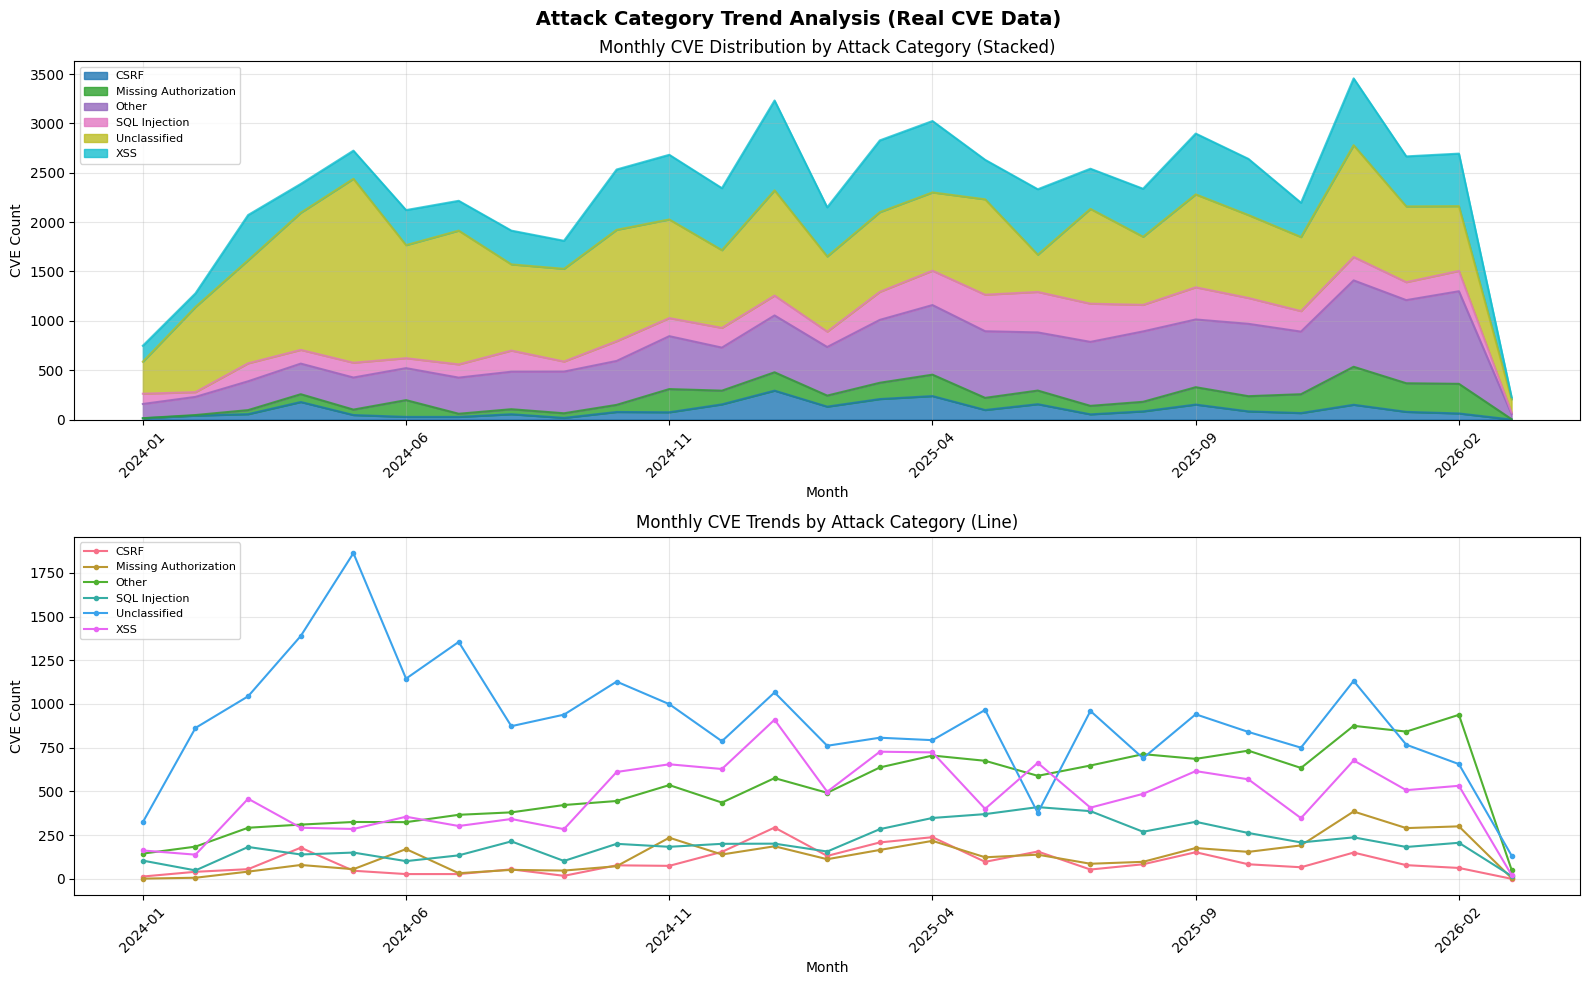


 Monthly CVE Counts by Category (Last 6 months):
attack_category  CSRF  Missing Authorization  Other  SQL Injection  Unclassified  XSS
month_year                                                                           
2025-10            83                    154    733            262           840  569
2025-11            66                    191    634            208           750  347
2025-12           150                    385    875            237          1132  677
2026-01            78                    290    842            182           767  507
2026-02            62                    300    938            206           656  532
2026-03             0                      4     52             16           133   22


In [17]:
print('\n' + '=' * 70)
data['month_year'] = data['date_published'].dt.to_period('M')

# Use top 6 categories (parallel to the 6 types in synthetic data)
top6_cats = data['attack_category'].value_counts().head(6).index.tolist()
cat_data = data[data['attack_category'].isin(top6_cats)]
monthly_type = cat_data.groupby(['month_year', 'attack_category']).size().unstack(fill_value=0)

# Filter to recent 3 years
recent_monthly = monthly_type[monthly_type.index >= pd.Period(cutoff_date, freq='M')]

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle(' Attack Category Trend Analysis (Real CVE Data)', fontsize=14, fontweight='bold')

recent_plot = recent_monthly.copy()
recent_plot.index = recent_plot.index.astype(str)

recent_plot.plot(kind='area', stacked=True, ax=axes[0], colormap='tab10', alpha=0.8)
axes[0].set_title('Monthly CVE Distribution by Attack Category (Stacked)')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('CVE Count')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(loc='upper left', fontsize=8)

recent_plot.plot(kind='line', ax=axes[1], marker='o', markersize=3, linewidth=1.5)
axes[1].set_title('Monthly CVE Trends by Attack Category (Line)')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('CVE Count')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / '12_category_trends.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n Monthly CVE Counts by Category (Last 6 months):')
print(recent_monthly.tail(6).to_string())

## Step 14: Summary and Conclusions

In [18]:
print('\n' + '=' * 70)
print('      FORECASTING CVE PUBLICATIONS — PHASE 1 COMPLETE SUMMARY')
print()
print(' Dataset:')
print(f'   Data Source         : cvelistV5 (Official CVE Database)')
print(f'   Total CVE records   : {len(data):,}')
print(f'   Full Date Range     : {data["date_published"].min().date()} → {data["date_published"].max().date()}')
print(f'   Modeled Period      : {recent_data["date"].min().date()} → {recent_data["date"].max().date()} ({len(recent_data)} days)')
print(f'   Training days       : {train_size}')
print(f'   Testing days        : {len(recent_data) - train_size}')
print()
print(' Model Results (sorted by RMSE):')
print(results[['Rank', 'Model', 'Type', 'MAE', 'RMSE', 'MAPE (%)']].to_string(index=False))
print()
print(' Best Performing Model:')
best = results.iloc[0]
print(f'   {best["Model"]} ({best["Type"]})')
print(f'   MAE={best["MAE"]:.4f}  RMSE={best["RMSE"]:.4f}  MAPE={best["MAPE (%)"]:.2f}%')
print()
print(' Features Used:')
for f in FEATURES:
    print(f'   • {f}')
print()
print('  Roadmap:')
print('    Phase 1  — Baseline Forecasting (ARIMA, RF, XGBoost, SVR, LSTM) — DONE')
print('    Phase 2  — Deep Learning (Full LSTM, BiLSTM, Transformer)')
print('    Phase 3  — Graph Neural Network (Threat-Technology Graph)')
print('    Phase 4  — Threat-Technology Gap Forecasting & Dashboard')
print()
print(f' All outputs saved to: {OUTPUT_DIR}')
# Save results CSV
results.to_csv(OUTPUT_DIR / 'model_results.csv', index=False)
daily_cves.to_csv(OUTPUT_DIR / 'daily_cve_timeseries.csv', index=False)
print(f'\n Results saved to {OUTPUT_DIR / "model_results.csv"}')
print(f' Daily time-series saved to {OUTPUT_DIR / "daily_cve_timeseries.csv"}')


      FORECASTING CVE PUBLICATIONS — PHASE 1 COMPLETE SUMMARY

 Dataset:
   Data Source         : cvelistV5 (Official CVE Database)
   Total CVE records   : 84,936
   Full Date Range     : 2024-01-01 → 2026-03-03
   Modeled Period      : 2024-01-01 → 2026-03-03 (791 days)
   Training days       : 632
   Testing days        : 159

 Model Results (sorted by RMSE):
 Rank         Model              Type       MAE      RMSE   MAPE (%)
    1 Random Forest       Ensemble ML 49.692699 69.512164  66.156174
    2     SVR (RBF)         Kernel ML 47.978969 73.506876  52.432160
    3       XGBoost Gradient Boosting 54.686565 74.638330  83.981085
    4          LSTM     Deep Learning 56.623609 79.453571  84.465295
    5  ARIMA(5,1,0)       Statistical 76.179519 96.844086 207.008413

 Best Performing Model:
   Random Forest (Ensemble ML)
   MAE=49.6927  RMSE=69.5122  MAPE=66.16%

 Features Used:
   • day_of_week
   • month
   • day_of_year
   • week_of_year
   • is_weekend
   • quarter
   • rolling_